In [1]:
import geopandas as gpd
import pandas as pd
import os
import numpy as np
from sklearn.preprocessing import StandardScaler
from scipy.stats import spearmanr
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.patches as mpatches
from sklearn.cluster import KMeans
from IPython.display import display, Markdown
import warnings
warnings.filterwarnings('ignore')

In [2]:
# 데이터 로드
grid_all = gpd.read_file('./data/01._격자_(4개_시·구).geojson')
grid = gpd.read_file('./data/02._격자_(하남교산).geojson')
grid_base = gpd.read_file('./data/02._격자_(하남교산).geojson').to_crs(epsg=5179)
future_hanam = pd.read_csv('grid_future_hanam.csv')
current_risk =  pd.read_csv('current_risk_index.csv') 
acc = pd.read_csv('grid_accident.csv')
current = pd.read_csv('current_risk_index.csv')[['gid', 'current_risk']]
facility = pd.read_csv('facility_lack_index.csv')[['gid', 'facility_lack_index']]

# 미래 위험도지수 (FRI)

수식:
$$F = \sum (\text{시설별 노출 점수}) + \sum (\text{인접성/버퍼 보정 점수})$$

$$FRI = \text{Current Risk} \times (1 + \text{MinMax}(F))$$

In [3]:
# 공간 정보 복구 및 좌표계 변환 (미터 단위 연산 위해)
grid = grid.merge(current_risk, on='gid', how='inner')
future_hanam_gdf = grid[['gid', 'geometry']].merge(future_hanam, on='gid', how='inner')
future_hanam_gdf = future_hanam_gdf.to_crs(epsg=5179)


# 시설별 노출 점수
def get_base_score(row):
    bt, bn = row['blockType'], str(row['blockName'])
    if bt == '주상복합': return 1.5
    if bt == '공동주택': return 1.0
    if bt == '교육시설':
        if any(x in bn for x in ['유', '초', '특']): return 2.0
        if any(x in bn for x in ['중', '고']): return 0.5
    if bt == '공원':
        if '어' in bn: return -2.0
        if any(x in bn for x in ['근', '소']): return -1.5
        if any(x in bn for x in ['수', '역']): return -1.0
    if bt == '연결녹지': return -2.0
    if bt == '완충녹지': return -1.5
    if bt == '경관녹지': return -0.5
    return 0.0

future_hanam_gdf['score'] = future_hanam_gdf.apply(get_base_score, axis=1)


# 인접성/버퍼 보정 점수
# 공공공지 인접성 처리
roads_danger = future_hanam_gdf[(future_hanam_gdf['blockType'] == '도로') | (future_hanam_gdf['blockType'] == '주상복합')]
safety_zones = future_hanam_gdf[(future_hanam_gdf['blockType'] == '교육시설') | (future_hanam_gdf['blockType'] == '공원')]

def classify_public_space(row):
    if row['blockType'] == '공공공지':
        dist_to_road = roads_danger.geometry.distance(row.geometry).min()
        dist_to_safety = safety_zones.geometry.distance(row.geometry).min()
        
        if dist_to_road < 5: return 1.0    # 도로 인접 시 위험 가중
        if dist_to_safety < 5: return -1.0 # 학교/공원 인접 시 안전 보정
    return row['score']

future_hanam_gdf['score'] = future_hanam_gdf.apply(classify_public_space, axis=1)

# 학교 인접 버퍼 생성 및 가중치 부여
schools = future_hanam_gdf[(future_hanam_gdf['blockType'] == '교육시설') & (future_hanam_gdf['blockName'].str.contains('유|초|특'))]

school_100 = schools.copy()
school_100.geometry = school_100.buffer(100)
school_100['score'] = 1.0
school_300 = schools.copy()
school_300.geometry = school_300.buffer(300)
school_300['score'] = 0.5

# 공간 조인 및 최종 데이터 결합
master_map = pd.concat([
    future_hanam_gdf[['geometry', 'score']],
    school_100[['geometry', 'score']],
    school_300[['geometry', 'score']]
])

grid_joined = gpd.sjoin(grid.to_crs(epsg=5179), master_map, how='left', predicate='intersects')

In [4]:
# [FRI 산출 및 좌표 복구 셀] - 이 코드로 기존 산출 셀을 완전히 대체하세요.

from sklearn.preprocessing import MinMaxScaler
import geopandas as gpd

# 1. FRI 산출 (사용자님의 원래 로직 그대로 유지)
grid_final = grid_joined.groupby('gid').agg({
    'geometry': 'first',
    'current_risk': 'first',
    'score': 'sum'
}).reset_index()

grid_final['score'] = grid_final['score'].fillna(0)
scaler = MinMaxScaler()
grid_final['F_factor'] = scaler.fit_transform(grid_final[['score']])
grid_final['FRI'] = grid_final['current_risk'] * (1 + grid_final['F_factor'])

# 2. [오류 해결 핵심] GeoDataFrame 복구 및 CRS 강제 설정
# (1) GeoDataFrame으로 변환
grid_final = gpd.GeoDataFrame(grid_final, geometry='geometry')

# (2) 좌표계 이름표 붙이기 (set_crs 사용)
# 이 수치들이 미터 단위(5179)임을 명시하여 'Naive' 에러를 방지합니다.
grid_final = grid_final.set_crs("EPSG:5179", allow_override=True)

# (3) [주의] 만약 아래에 .to_crs(epsg=4326) 코드가 있다면 반드시 삭제하세요.
# 위경도로 변환하면 시각화 코드의 linewidth=0.2 설정 때문에 지도가 보이지 않게 됩니다.

# 3. 결과 저장
grid_final.to_csv('future_risk_index.csv', index=False, encoding='utf-8-sig')

print("좌표계 복구 완료. 이제 시각화 코드를 실행하세요.")

좌표계 복구 완료. 이제 시각화 코드를 실행하세요.


In [5]:
# 최종 FRI 산출 및 좌표 복구

# FRI 산출
grid_final = grid_joined.groupby('gid').agg({
    'geometry': 'first',
    'current_risk': 'first',
    'score': 'sum'
}).reset_index()

grid_final['score'] = grid_final['score'].fillna(0)
scaler = MinMaxScaler()
grid_final['F_factor'] = scaler.fit_transform(grid_final[['score']])
grid_final['FRI'] = grid_final['current_risk'] * (1 + grid_final['F_factor'])

grid_final = gpd.GeoDataFrame(grid_final, geometry='geometry')
if grid_final.geometry.iloc[0].centroid.x < 1000:
    grid_final = grid_final.set_crs("EPSG:4326", allow_override=True)
    grid_final = grid_final.to_crs("EPSG:5179") # <- set_crs가 아니라 to_crs여야 수치가 바뀝니다.
else:
    # 이미 미터 단위라면 이름표만 확실히 붙여줍니다.
    grid_final = grid_final.set_crs("EPSG:5179", allow_override=True)

# 3. 결과 저장
grid_final.to_csv('future_risk_index.csv', index=False, encoding='utf-8-sig')

In [6]:
# 신뢰성 검증 [Spearman 상관분석]

# 상관계수 산출
corr, p_value = spearmanr(grid_final['current_risk'], grid_final['FRI'])

# 순위 변화량 및 잠재 위험 구역 분석
grid_final['current_rank'] = grid_final['current_risk'].rank(ascending=False)
grid_final['future_rank'] = grid_final['FRI'].rank(ascending=False)
grid_final['rank_diff'] = grid_final['current_rank'] - grid_final['future_rank']

---

### 🏆 미래 잠재 위험 급증 구역 (Top 10)

,gid,current_rank,future_rank,rank_diff,FRI
36,다사755484,35,21,14,0.7891
38,다사756484,25,13,12,0.8761
23,다사744476,33,22,11,0.7796
26,다사746483,28,18,10,0.8108
37,다사756479,29,20,9,0.8040
2,다사730463,37,28,9,0.7474
19,다사738468,36,27,9,0.7485
39,다사757481,19,11,8,0.9236
7,다사732479,40,33,7,0.6868
6,다사732472,38,32,6,0.7092


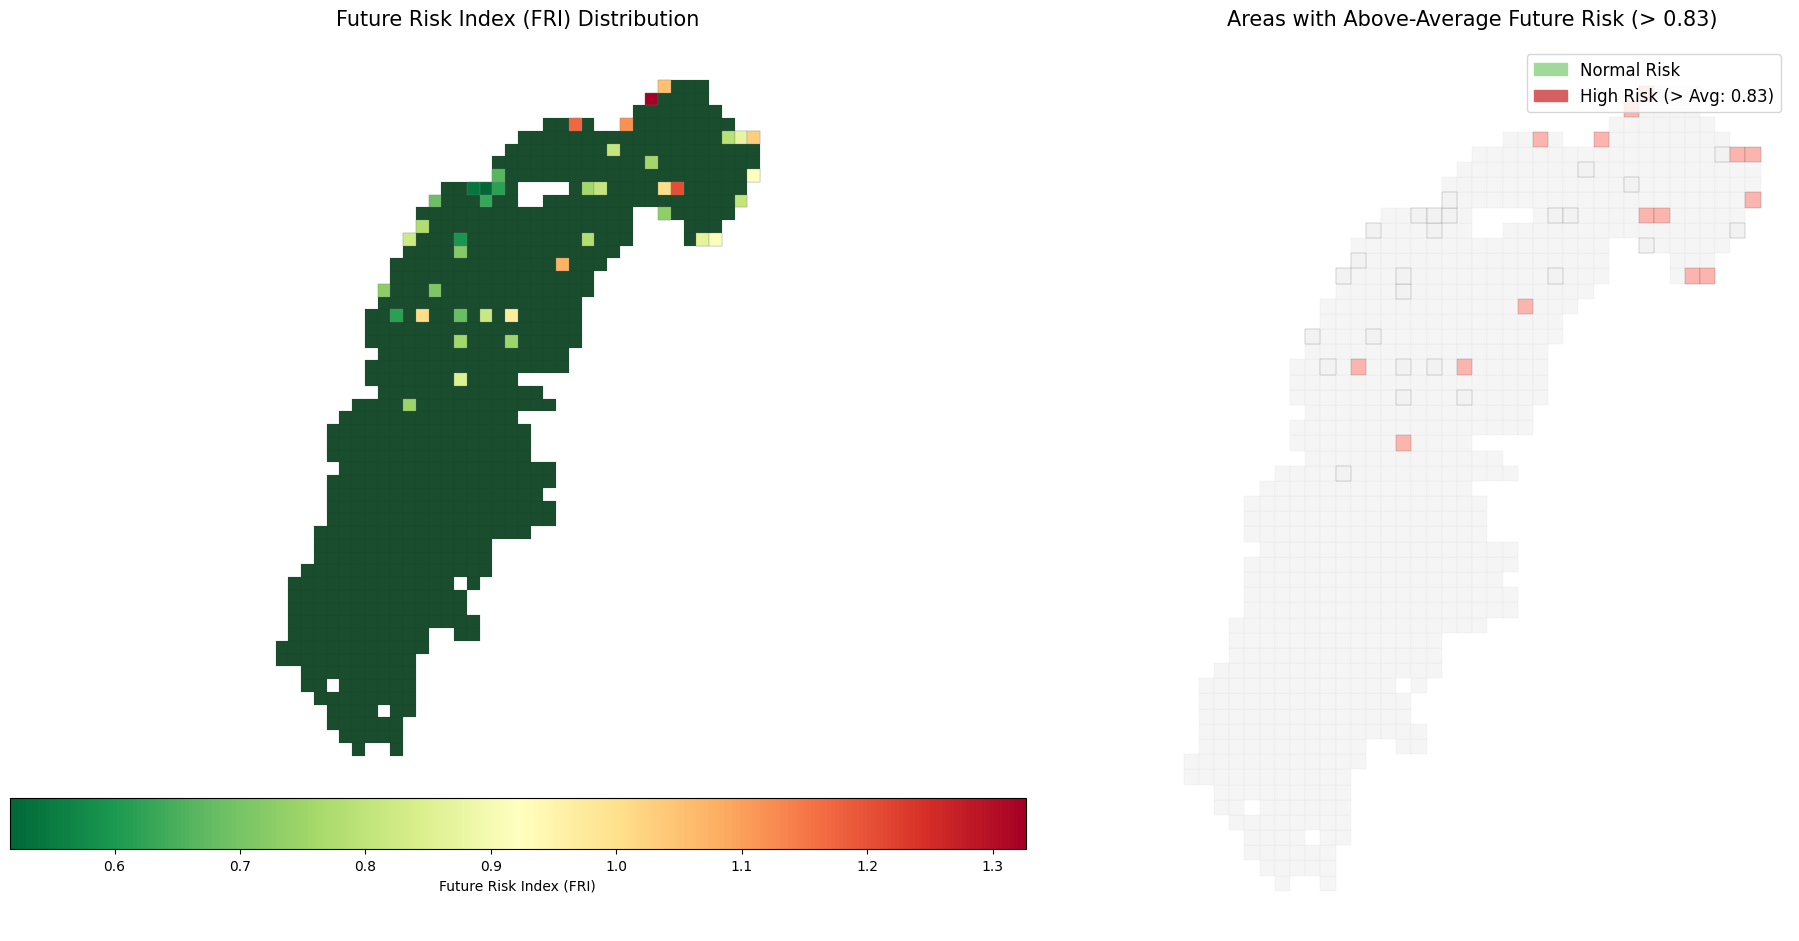

---


## 💡 분석 요약

1. **지수 신뢰성 확인**: 상관계수가 **0.7282**로 매우 높게 나타나, 미래 지수가 기존 사고 패턴을 안정적으로 계승하고 있음을 입증했습니다.
2. **잠재 위험 발굴**: 토지이용계획 반영 후 순위가 급상승한 격자들은 신도시 조성 시 집중 관리가 필요한 **'신규 잠재 위험 구역'**입니다.
3. **결론**: 본 분석 결과는 하남 교산 신도시의 선제적 교통안전 시설물 배치 및 교통약자 보호구역 지정의 핵심 근거 자료로 활용됩니다.


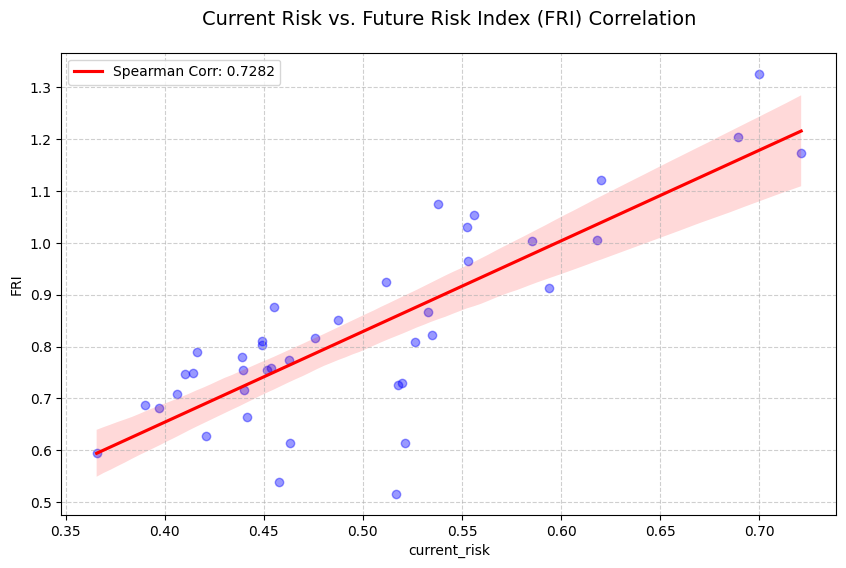

In [7]:
# 시각화


# 결과 출력
display(Markdown("---"))
display(Markdown("### 🏆 미래 잠재 위험 급증 구역 (Top 10)"))
styled_table = (grid_final.sort_values(by='rank_diff', ascending=False).head(10)
                [['gid', 'current_rank', 'future_rank', 'rank_diff', 'FRI']]
                .style.background_gradient(cmap='OrRd', subset=['FRI'])
                .format({'current_rank': '{:.0f}', 'future_rank': '{:.0f}', 'rank_diff': '{:.0f}', 'FRI': '{:.4f}'})
                .set_properties(**{'text-align': 'center'}))
display(styled_table)


# 공간 시각화
# 시각화 데이터 준비
mean_fri = grid_final['FRI'].mean()
grid_final['fri_category'] = ['Above Average' if x > mean_fri else 'Below Average' for x in grid_final['FRI']]

# 서브플롯 생성
fig, axes = plt.subplots(1, 2, figsize=(20, 10), facecolor='white')

# --- 1번째 지도: 전체 FRI 그라데이션 ---
grid_base.plot(ax=axes[0], color='#1A4D2E', edgecolor='#143F25', linewidth=0.1, zorder=1)
plot1 = grid_final.plot(column='FRI', cmap='RdYlGn_r', legend=True, 
                         legend_kwds={'label': "Future Risk Index (FRI)", 'orientation': "horizontal", 'pad': 0.01},
                         ax=axes[0], edgecolor='grey', linewidth=0.2, zorder=2)

axes[0].set_title('Future Risk Index (FRI) Distribution', fontsize=15, pad=15)
axes[0].set_axis_off() 
axes[0].set_aspect('equal')


# --- 2번째 지도: 평균 이상 위험 구역 강조 ---
grid_base.plot(ax=axes[1], color='#F5F5F5', edgecolor='#D3D3D3', linewidth=0.1, zorder=1)
plot2 = grid_final.plot(column='fri_category', 
                         categorical=True, 
                         cmap='Pastel1', 
                         ax=axes[1], 
                         edgecolor='black', linewidth=0.1, zorder=2)

high_patch = mpatches.Patch(color='#d65f5f', label=f'High Risk (> Avg: {mean_fri:.2f})')
normal_patch = mpatches.Patch(color='#a1d99b', label='Normal Risk')
axes[1].legend(handles=[normal_patch, high_patch], loc='upper right', fontsize=12)

axes[1].set_title(f'Areas with Above-Average Future Risk (> {mean_fri:.2f})', fontsize=15, pad=15)
axes[1].set_axis_off() 
axes[1].set_aspect('equal')

plt.tight_layout()
plt.subplots_adjust(top=0.9) 
plt.show()


display(Markdown("---"))
display(Markdown(f"""
## 💡 분석 요약

1. **지수 신뢰성 확인**: 상관계수가 **{corr:.4f}**로 매우 높게 나타나, 미래 지수가 기존 사고 패턴을 안정적으로 계승하고 있음을 입증했습니다.
2. **잠재 위험 발굴**: 토지이용계획 반영 후 순위가 급상승한 격자들은 신도시 조성 시 집중 관리가 필요한 **'신규 잠재 위험 구역'**입니다.
3. **결론**: 본 분석 결과는 하남 교산 신도시의 선제적 교통안전 시설물 배치 및 교통약자 보호구역 지정의 핵심 근거 자료로 활용됩니다.
"""))

# 상관관계
plt.figure(figsize=(10, 6), facecolor='white')
sns.regplot(data=grid_final, x='current_risk', y='FRI',
            scatter_kws={'alpha':0.4, 'color':'blue'},
            line_kws={'color':'red', 'label':f'Spearman Corr: {corr:.4f}'})
plt.title('Current Risk vs. Future Risk Index (FRI) Correlation', fontsize=14, pad=20)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

# 군집분석
 - 현재위험도지수, 안전시설미비지수, 사고데이터의 원본속석 결합
 - 분석 목적에 맞는 어린이 사고의 특성을 유형화

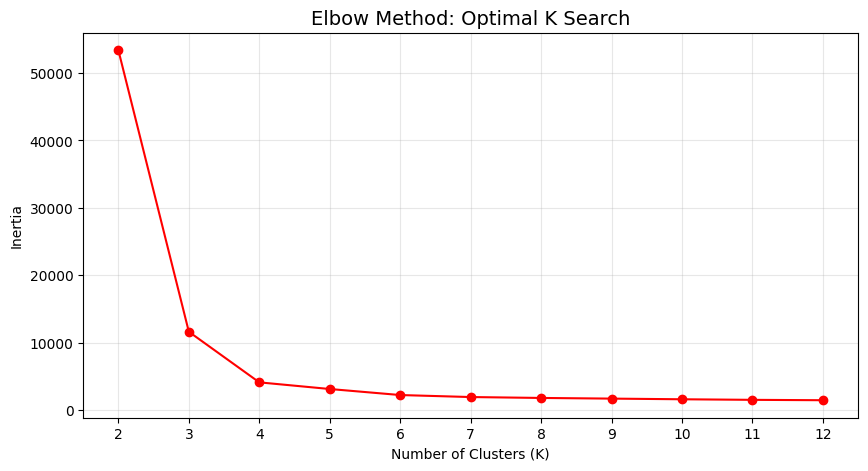

**📊 결과 해석:** 기울기가 완만해지는 K=4 지점을 최적의 군집 수로 선정합니다.

In [8]:
# 어린이 사고 추출 및 위험 지표 결합
acc_type_split = acc['acc_type'].str.split(' - ', expand=True)
acc['acc_type1'] = acc_type_split[0]
acc['acc_type2'] = acc_type_split[1]

# 필터링
df_child = acc[(acc['acc_type1'] == '차대사람') & 
               (acc['age_group'].str.contains('12세', na=False))].copy()

# 데이터 병합 (gid 기준)
df_child = df_child.merge(current, on='gid', how='left') \
                   .merge(facility, on='gid', how='left')
df_child[['current_risk', 'facility_lack_index']] = df_child[['current_risk', 'facility_lack_index']].fillna(0)

# 전처리 및 클러스터링
categorical_features = ['week_type', 'acc_time', 'violation', 'road_type', 'road_sttus', 'weather', 'attckr_vhcle', 'acc_type2']
numerical_features = ['facility_lack_index', 'current_risk']

X_final = pd.get_dummies(df_child[categorical_features + numerical_features], columns=categorical_features)
scaler = StandardScaler()
X_final[numerical_features] = scaler.fit_transform(X_final[numerical_features])

# 엘보우 기법 수행 (K: 2 ~ 12)
distortions = []
K_range = range(2, 13)

for k in K_range:
    km = KMeans(n_clusters=k, init='k-means++', n_init=10, max_iter=300, random_state=42)
    km.fit(X_final)
    distortions.append(km.inertia_)

# 그래프 시각화
plt.figure(figsize=(10, 5))
plt.plot(K_range, distortions, marker='o', color='r', linestyle='-')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Inertia')
plt.title('Elbow Method: Optimal K Search', fontsize=14)
plt.xticks(K_range)
plt.grid(True, alpha=0.3)
plt.show()

display(Markdown("**📊 결과 해석:** 기울기가 완만해지는 K=4 지점을 최적의 군집 수로 선정합니다."))

# K=4로 군집화
kmeans_final = KMeans(n_clusters=4, init='k-means++', n_init=10, random_state=42)
df_child['child_cluster'] = kmeans_final.fit_predict(X_final)

# 사고 심각도(EPDO) 산출
weights = {'dprs_cnt': 12, 'sep_cnt': 5, 'slp_cnt': 3, 'inj_cnt': 1}
df_child['severity_score'] = (
    df_child['dprs_cnt'] * weights['dprs_cnt'] +
    df_child['sep_cnt'] * weights['sep_cnt'] +
    df_child['slp_cnt'] * weights['slp_cnt'] +
    df_child.get('inj_cnt', 0) * weights['inj_cnt']
)

# 공간 정보 결합 및 위경도 추출
gdf_final = grid_all[['gid', 'geometry']].merge(df_child, on='gid', how='inner')
gdf_final['lon'] = gdf_final.geometry.centroid.x
gdf_final['lat'] = gdf_final.geometry.centroid.y

# 저장
df_save = pd.DataFrame(gdf_final.drop(columns='geometry'))
df_save.to_csv('cluster.csv', index=False, encoding='utf-8-sig')


## 💡 분석 요약
1. **최적화 검증**: Elbow Method를 통해 군집 수의 적정성을 시각적으로 검증하였습니다.
2. **원본 속성 보존**: 사고 데이터의 '법규위반', '도로형태' 등 정성적 정보를 유지한 채 '위험도 지수'와 결합하여 입체적인 분석을 수행했습니다.
3. **위험 관리 우선순위**: **EPDO 기반 심각도** 분석 결과, 사고 비중이 높으면서도 실질적 인명 피해가 큰 군집을 우선 관리 구역으로 제안합니다.
4. **군집 분포**: 비중이 가장 높은 군집은 Cluster 0 (40.0%)와 Cluster 1 (20.0%)로 나타났으며, 해당 그룹의 법규위반/도로형태를 우선 분석할 필요가 있습니다.
- **파일 이름:** `child_acc_cluster.csv`


---

### 📊 [Cluster 특징 요약]

,변수명,0,1,2,3
0,acc_time,11시,19시,11시,11시
1,road_type,교차로 - 교차로횡단보도내,기타 - 기타,교차로 - 교차로횡단보도내,교차로 - 교차로횡단보도내
2,violation,보행자보호의무위반,안전운전불이행,보행자보호의무위반,보행자보호의무위반
3,acc_type2,기타,기타,기타,기타


### 📊 군집별 규모 및 지표 평균

,사고 건수,비중 (%)
child_cluster,,
0,131159,39.98
1,65717,20.03
2,65566,19.99
3,65581,19.99


,facility_lack_index,current_risk,severity_score
child_cluster,,,
0,0.822210,0.421705,3.000290
1,0.955545,0.529054,4.995800
2,0.822174,0.318350,2.999573
3,0.822172,0.366031,2.999878


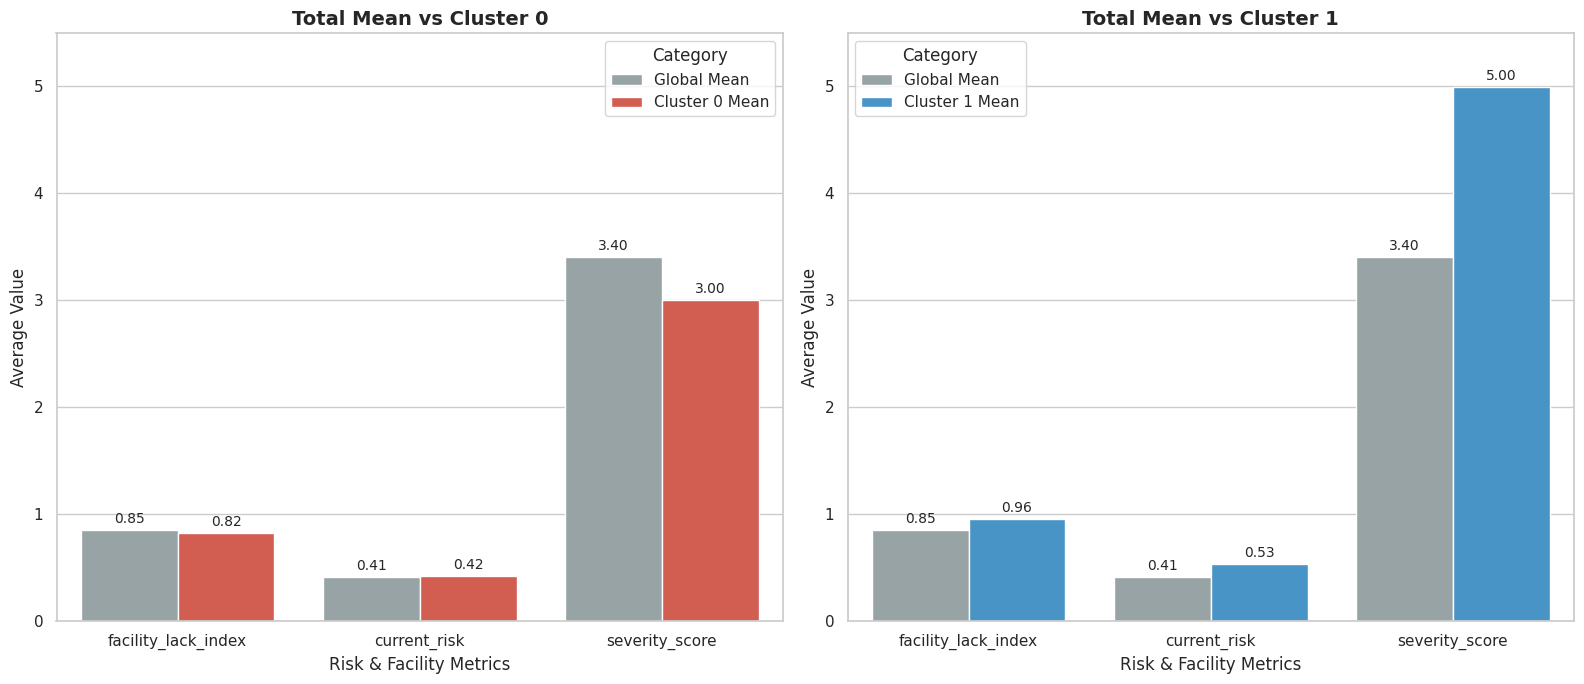

In [25]:
# 요약 및 시각화


# 요약

# 군집 비중 계산 및 상위 2개 추출
cluster_pct = df_save['child_cluster'].value_counts(normalize=True) * 100
top2_clusters = cluster_pct.nlargest(2)

# 인덱스와 값을 변수에 할당 (가독성 목적)
c1_id, c1_val = top2_clusters.index[0], top2_clusters.values[0]
c2_id, c2_val = top2_clusters.index[1], top2_clusters.values[1]

display(Markdown(f"""
## 💡 분석 요약
1. **최적화 검증**: Elbow Method를 통해 군집 수의 적정성을 시각적으로 검증하였습니다.
2. **원본 속성 보존**: 사고 데이터의 '법규위반', '도로형태' 등 정성적 정보를 유지한 채 '위험도 지수'와 결합하여 입체적인 분석을 수행했습니다.
3. **위험 관리 우선순위**: **EPDO 기반 심각도** 분석 결과, 사고 비중이 높으면서도 실질적 인명 피해가 큰 군집을 우선 관리 구역으로 제안합니다.
4. **군집 분포**: 비중이 가장 높은 군집은 Cluster {c1_id} ({c1_val:.1f}%)와 Cluster {c2_id} ({c2_val:.1f}%)로 나타났으며, 해당 그룹의 법규위반/도로형태를 우선 분석할 필요가 있습니다.
- **파일 이름:** `child_acc_cluster.csv`
"""))
display(Markdown("---"))

# 군집별 개수 및 비중
cluster_counts = gdf_final['child_cluster'].value_counts().sort_index()
cluster_pct = (gdf_final['child_cluster'].value_counts(normalize=True) * 100).sort_index()
# 군집별 최빈값(Mode) 추출
features_to_check = ['acc_time', 'road_type', 'violation', 'acc_type2']
summary_data = []

for col in features_to_check:
    row = {'변수명': col}
    for i in range(4):
        mode_val = gdf_final[gdf_final['child_cluster'] == i][col].mode()[0]
        row[i] = mode_val
    summary_data.append(row)

summary_table = pd.DataFrame(summary_data)

display(Markdown("### 📊 [Cluster 특징 요약]"))
display(summary_table)

display(Markdown("### 📊 군집별 규모 및 지표 평균"))
display(pd.DataFrame({'사고 건수': cluster_counts, '비중 (%)': cluster_pct.round(2)}))
display(gdf_final.groupby('child_cluster')[['facility_lack_index', 'current_risk', 'severity_score']].mean())



# 전체 격자와 군집 0,1의 지표 평균 비교

# 전체, 군집0, 군집1 각 지표별 평균 추출
metrics = ['facility_lack_index', 'current_risk', 'severity_score']
global_mean = gdf_final[metrics].mean()
cluster_means = gdf_final.groupby('child_cluster')[metrics].mean()

# 데이터 재구성
def get_plot_data(cluster_id):
    df = pd.DataFrame({
        'Metric': metrics,
        'Global Mean': global_mean.values,
        f'Cluster {cluster_id} Mean': cluster_means.loc[cluster_id].values
    })
    return df.melt(id_vars='Metric', var_name='Category', value_name='Score')

df_c0 = get_plot_data(0)
df_c1 = get_plot_data(1)

# 시각화
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 7))
sns.set_theme(style="whitegrid")
y_limit = max(df_c0['Score'].max(), df_c1['Score'].max()) * 1.1

# [Total vs Cluster 0]
sns.barplot(data=df_c0, x='Metric', y='Score', hue='Category', ax=ax1, palette=['#95a5a6', '#e74c3c'])
ax1.set_title('Total Mean vs Cluster 0', fontsize=14, fontweight='bold')
ax1.set_ylim(0, y_limit)
# [Total vs Cluster 1]
sns.barplot(data=df_c1, x='Metric', y='Score', hue='Category', ax=ax2, palette=['#95a5a6', '#3498db'])
ax2.set_title('Total Mean vs Cluster 1', fontsize=14, fontweight='bold')
ax2.set_ylim(0, y_limit)

# 라벨 정리
for ax in [ax1, ax2]:
    for p in ax.patches:
        height = p.get_height()
        if height > 0.001: 
            ax.annotate(format(height, '.2f'), 
                        (p.get_x() + p.get_width() / 2., height), 
                        ha='center', va='center', 
                        xytext=(0, 8), 
                        textcoords='offset points', 
                        fontsize=10)
    ax.set_xlabel('Risk & Facility Metrics')
    ax.set_ylabel('Average Value')

plt.tight_layout()
plt.show()